# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 1.2 - Training from Scratch (with seed 42)

**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook is has the same process as [01_task1_scratch.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch.ipynb) and [01_task1_scratch_3.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch_3.ipynb) with only the difference being the random seed set. Which for this notebook the seed is 42.

In this notebook, a classification model is trained from scratch, using the dataset [Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) and the data split analised in the previous notebook ([00_data_exploration.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb)). The training is performed independantly over different fractions of the training database (10%, 25%, 50%, 75% and 100%), and the summary of metrics and plots are shown and downloaded in a zip format.

**Observation:**

1.   The first six (6) cells of code bellow were implemented to be able to run the notebook using Google Colab mantainig it connected to the GitHub project. The rest o the code was initially wroten using DataSpell.
2.   This notebook demanded around 5 hours to ran completly, it can be interesting to break the for loop in cell 7 to run each fraction of tha training data independently.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [3]:
import sys
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torchvision import datasets, transforms

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [5]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          translate_names, get_data_loaders)
from tasks.task1 import train_from_scratch

data_fractions = Config.DATA_FRACTIONS
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
Config.RANDOM_SEED = 42
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on notebook 00_data_exploration
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=random_seed
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [6]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.31it/s]



 Epoch 1/100:
 Train Loss: 3.0970, Train Acc: 16.70%
 Val Loss: 11.4266, Val Acc: 13.50%
Saved best model (Val Acc: 13.50%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.53it/s]



 Epoch 2/100:
 Train Loss: 2.2378, Train Acc: 19.00%
 Val Loss: 2.2049, Val Acc: 18.00%
Saved best model (Val Acc: 18.00%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.51it/s]



 Epoch 99/100:
 Train Loss: 0.7145, Train Acc: 76.26%
 Val Loss: 1.3126, Val Acc: 58.21%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.57it/s]


 Epoch 100/100:
 Train Loss: 0.7004, Train Acc: 77.29%
 Val Loss: 1.3098, Val Acc: 58.26%
Training completed in 1735.80 seconds.



 Test Results: 
 Accuracy: 58.54%
 Precision: 59.51%
 Recall: 58.54%
 F1-score: 58.41%


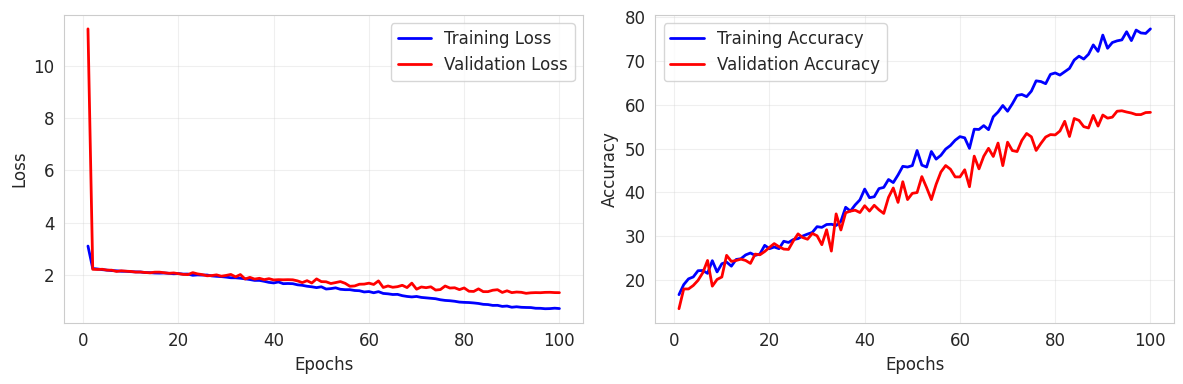

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.10.json

Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.20it/s]



 Epoch 1/100:
 Train Loss: 2.6805, Train Acc: 18.73%
 Val Loss: 2.3243, Val Acc: 21.44%
Saved best model (Val Acc: 21.44%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.62it/s]



 Epoch 2/100:
 Train Loss: 2.1905, Train Acc: 20.93%
 Val Loss: 2.1669, Val Acc: 21.24%


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.63it/s]



 Epoch 41/100:
 Train Loss: 1.1311, Train Acc: 60.49%
 Val Loss: 1.4548, Val Acc: 53.65%
Saved best model (Val Acc: 53.65%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.69it/s]



 Epoch 42/100:
 Train Loss: 1.1388, Train Acc: 61.23%
 Val Loss: 1.3315, Val Acc: 55.44%
Saved best model (Val Acc: 55.44%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


Epoch 43:  32%|███▏      | 23/72 [00:07<00:15,  3.20it/s, loss: 1.1764724150947903, accuracy: 58.49184782608695]

In [ ]:
# Task 1: Train ResNet-18 from scratch for each data fraction
all_results = []

for frac in data_fractions:
  print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

  train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=random_seed,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
  )

  result = train_from_scratch(
        config=Config,
        data_fraction=frac,
        version_RestNet=18,
        save_model=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader
  )

  all_results.append(result)

print("\nFinished training for all fractions.")

In [ ]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / f"task1_scratch_all_fractions_summary_{random_seed}.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

In [ ]:
from IPython.display import Image, display

for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task1_scratch_learning_curves_{frac:.2f}_{random_seed}.png"
    if plot_path.exists():
        print(f"\nLearning curves for fraction = {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

In [ ]:
!zip -r results_task1_42.zip /content/TOL506M_Final_Project/results/

In [ ]:
from google.colab import files
files.download("results_task1_42.zip")